In [1]:
import numpy as np
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
import matplotlib.animation as animation
from matplotlib.patches import ConnectionPatch, Rectangle

from numpy import datetime64 as dt
from numpy import timedelta64 as td

import cmocean
import xarray as xr
from glob import glob
import cartopy
from cartopy.crs import Geodetic, PlateCarree, Stereographic
import warnings

import pandas as pd
import geopandas as gpd
import seaborn as sns

warnings.simplefilter("ignore")

In [2]:
import numpy as np
from numpy import pi

sigma = 5.67e-8
Temperature_Sun = 5774
Radius_Sun = 696000
distance = 1.5e8
albedo = 0.32
wiens_constant = 2898

Surface_Sun = 4*pi*Radius_Sun**2
Irradiance_Sun = sigma * Temperature_Sun**4

E_S = Irradiance_Sun*Surface_Sun
# print(E_S)
Solar_constant = E_S/(distance**2*4*pi)
print("Solarconstant: ", np.round(Solar_constant, 2))

Average_Solar_Radiation_Earth = Solar_constant/4
print("Average solar Radition: ", np.round(Average_Solar_Radiation_Earth, 2))

Temperature_Earth = ((1-albedo)*Average_Solar_Radiation_Earth/sigma)**(1/4)
print("Temperature earth: ", np.round(Temperature_Earth, 2))

print("wavelegth max earth", np.round(wiens_constant/Temperature_Earth, 2), "micro meters")
print("wavelegth max sun", np.round(wiens_constant/Temperature_Sun, 2), "micro meters")

Shortwave_radiation = 339
Albedo = 0.3
Atmospheric_absortpion = 0.6

Longwave_radiation_Earth = (Albedo *Shortwave_radiation/sigma)**(1/4)

Temp_earth = (((1 - Albedo) * Shortwave_radiation)/(sigma*(1 - Atmospheric_absortpion/2)))**(1/4)
Temp_Atmosphere = (Temp_earth**4/2)**(1/4)
print("Temperature earth: ", np.round(Temp_earth, 2))
print("Temperature atosphere: ", np.round(Temp_Atmosphere, 2))

(1-Albedo)*Shortwave_radiation*(1-Atmospheric_absortpion) + (1-Albedo)*Shortwave_radiation*(Atmospheric_absortpion*(1-Atmospheric_absortpion))
(sigma * Temp_earth**4 *(1-Atmospheric_absortpion/2))*Atmospheric_absortpion
print("longwave radiation TOA: ",(1 - Atmospheric_absortpion) * (Shortwave_radiation *(1- Albedo)+ Atmospheric_absortpion*Temp_earth**4*sigma))

CO2_ppm_2010 = 390
annual_CO2_growth = 2

Atmospheric_absortpion_2050 = Atmospheric_absortpion + 40*annual_CO2_growth*7.7e-5
Atmospheric_absortpion_double_CO2 = Atmospheric_absortpion + CO2_ppm_2010*7.7e-5
Temp_earth_2050 = (((1 - Albedo) * Shortwave_radiation)/(sigma*(1 - Atmospheric_absortpion_2050/2)))**(1/4)
Temp_earth_souble_CO2 = (((1 - Albedo) * Shortwave_radiation)/(sigma*(1 - Atmospheric_absortpion_double_CO2/2)))**(1/4)
Temp_Atmosphere_2050 = (Temp_earth_2050**4/2)**(1/4)
Temp_Atmosphere_double_CO2 = (Temp_earth_souble_CO2**4/2)**(1/4)
print("Temperature 2050 Earth: ",np.round(Temp_earth_2050, 2), np.round(Temp_Atmosphere_2050, 2))
print("Temperature double CO2 Earth: ", np.round(Temp_earth_souble_CO2, 2), np.round(Temp_Atmosphere_double_CO2, 2))
print("double CO2 reached: ",CO2_ppm_2010/annual_CO2_growth+2010)
thermal_expansion = (1357 + 1559)*1e-7/2*(Temp_earth_souble_CO2-Temp_earth)*900
print("Thermal expansion: " ,thermal_expansion)

Solarconstant:  1356.83
Average solar Radition:  339.21
Temperature earth:  252.55
wavelegth max earth 11.47 micro meters
wavelegth max sun 0.5 micro meters
Temperature earth:  278.07
Temperature atosphere:  233.83
longwave radiation TOA:  176.28
Temperature 2050 Earth:  278.38 234.09
Temperature double CO2 Earth:  279.58 235.1
double CO2 reached:  2205.0
Thermal expansion:  0.19833489651456188


# Set Parameters

In [3]:
# Paths
folder_path = "/gxfs_work/geomar/smomw597/2025_copepods/output/"
# trajectory_path = Path(folder_path, f"Trajectories/{year}/")
sample_Points_path = Path(folder_path, "SamplePoints/SamplePoints.shp")
voronoi_Polygons_path = Path(folder_path, "SamplePoints/VoronoiPolygons.shp")
voronoi_Ocean_path = Path(folder_path, "SamplePoints/VoronoiOceanPolygons.shp")
input_path = Path(folder_path, f"VoronoiConnectivity/")

In [4]:
# Load the samplepoints and the voronoi polygons
gdf_sample_points = gpd.read_file(sample_Points_path).to_crs(Geodetic())
gdf_voronoi_polygons = gpd.read_file(voronoi_Polygons_path).to_crs(Geodetic())
gdf_ocean_polygons = gpd.read_file(voronoi_Ocean_path).to_crs(Geodetic())

In [7]:
location_names_sorted = gdf_sample_points.sort_values(by="order").SampleID.tolist()
lons = gdf_sample_points.sort_values(by="order").geometry.x.values
lats = gdf_sample_points.sort_values(by="order").geometry.y.values
n_sites = len(gdf_sample_points)
nondigitalSamples = gdf_sample_points.sort_values(by="order").SampleID.where(gdf_sample_points.SampleKind != 'digital').reset_index().drop(columns='index')
digitalSamples = gdf_sample_points.sort_values(by="order").SampleID.where(gdf_sample_points.SampleKind == 'digital').reset_index().drop(columns='index')

years = np.arange(2016,2025)
n_years = len(years)

In [8]:
n_days = (np.datetime64("2016-11-01", "D") - np.datetime64("2016-06-01", "D")).astype("int")
n_timesteps_day = 24*4
n_days_life = 28
n_days_adult = 18
n_particles = 1000
# Check wether n_timesteps_day is needed oreven wrong here
n_total = n_days * n_years * n_timesteps_day * n_days_life * n_sites * n_particles
n30d = 30 * n_years * n_timesteps_day * n_days_life * n_sites * n_particles
n31d = 31 * n_years * n_timesteps_day * n_days_life * n_sites * n_particles

total_particle_count_per_site = n_days * n_years * n_particles
max_observation_single_particle = n_days_adult * n_timesteps_day

In [9]:
# Set the basic mapping parameters
suptitle_size = 20
title_size = 16
mapsize = (16, 8)
extent = (2.5, 27.5, 52, 62)
lonmid = np.mean(extent[:2])
latmid = np.mean(extent[2:])
map_projection = Stereographic(
    central_longitude=lonmid, central_latitude=latmid,
    )
def basemap(ax):
    ax.set_extent(extent, PlateCarree())
    ax.add_feature(LAND)
    ax.add_feature(COASTLINE)
    ax.gridlines(draw_labels=["left", "bottom"], y_inline=False,)
    return ax

In [10]:
# input_path = Path("/gxfs_work/geomar/smomw597/2025_copepods/output/")
figure_outpath = Path("/gxfs_work/geomar/smomw597/2025_copepods/Figures/")

# Functions

In [11]:
def sort_cmatrix(matrix_in):
    matrix = matrix_in[location_names_sorted + [c for c in matrix_in.columns if c not in location_names_sorted]]
    return matrix.reindex(location_names_sorted)

In [12]:
def map_sites(ax):
    return ax.scatter(
        lons, lats,
        transform=Geodetic(),
        c="magenta", s=25,
    )

In [13]:
def basemap(ax):
    ax.set_extent(extent, PlateCarree())
    ax.add_feature(cartopy.feature.LAND)
    ax.add_feature(cartopy.feature.COASTLINE)
    ax.gridlines(draw_labels=["left", "bottom"], y_inline=False,)
    return ax

In [14]:
def make_cbar(fig, ax, hist):
    cax = fig.add_axes(
        [
            ax.get_position().x1+0.01,
            ax.get_position().y0, 0.02,
            ax.get_position().height
        ]
    )
    return plt.colorbar(hist, cax=cax,)

In [ ]:
def highlight_single_cell(ax, idx):
        return ax.add_patch(Rectangle((idx, idx),1,1, fill=False, edgecolor='k', lw=1, zorder=3))

def highlight_col(ax, idx, length):
        ax.add_patch(Rectangle((idx, 0),1,length, fill=False, edgecolor='red', lw=1, zorder=1))
        return ax.add_patch(Rectangle((idx, 0),1,length, fill=True, color='red', edgecolor='red', lw=1, alpha=0.3, zorder=0))
def highlight_row(ax, idx, length):
        ax.add_patch(Rectangle((0, idx),length,1, fill=True, color='blue', lw=0.5, alpha=0.3, zorder=0))
        return ax.add_patch(Rectangle((0, idx),length,1, fill=False, edgecolor='blue', lw=1, zorder=1))

def draw_guides(ax):
        length = len(df_cmatrix_total.index)
        digitalSamples_list = digitalSamples.dropna().values.T[0]
        for idx_1, site_name in enumerate(df_cmatrix_total.index):
                highlight_single_cell(ax, idx_1)
                if site_name not in digitalSamples_list:
                        highlight_col(ax, idx_1, length)
                        highlight_row(ax, idx_1, length)
                for idx_2, site_name_2 in enumerate(df_cmatrix_total.index):
                        if (site_name_2 not in digitalSamples_list) and (site_name not in digitalSamples_list):
                                ax.add_patch(Rectangle((idx_2, idx_1),1,1, fill=False, edgecolor='purple', lw=3, zorder=2))
        return ax

In [201]:
def build_ax(ax, fontsize=10, labelpad=15, xlabelposition="top"):
        ax.xaxis.set_label_position(xlabelposition)  
        if xlabelposition == "top":
                ax.tick_params(
                        grid_linewidth=0, labelsize=fontsize, 
                        labelbottom=False, labeltop=True, 
                        size=0, pad=5,
                        )
        ax.set_yticklabels(ax.get_yticklabels(), rotation=90)
        ax.set_ylabel("Source Stations", size=fontsize, labelpad=labelpad)
        ax.set_xlabel("Target Stations", size=fontsize, labelpad=labelpad)
        return ax

def define_cmap(cmap_name='coolwarm', cmdiscrete=False,value_min=None, value_max=None):
        cmap = plt.get_cmap(cmap_name)
        vmax = 10**np.ceil(np.log10(value_max))
        vmin = 10**np.floor(np.log10(value_min))
        sample_steps = vmax-vmin
        bounds = np.arange(vmin, vmax+1)
        fmt = ".0f"
        norm = mpl.colors.Normalize(vmin=value_min, vmax=value_max)
        steps = (np.log10(vmax) - np.log10(vmin)).astype(int) # resample the colormap into the amount of discrete steps of difference between the vmin and vmax in power of 10
        if steps >2:
                sample_steps = steps
                bounds = np.logspace(np.log10(vmin), np.log10(vmax), steps+1)
                fmt = ".0e"
                norm = LogNorm(vmin=vmin, vmax=vmax,)
        if cmdiscrete == True:
                cmap = cmap.resampled(sample_steps)
                cmap.set_under(color="#00000000") # force the first color entry to be invisible
        return cmap, bounds, fmt, norm

def drop_digital(matrix, no_digital):
        if no_digital == True:
                digitalSamples_list = digitalSamples.dropna().values.T[0]
                return matrix.drop(columns=digitalSamples_list, index=digitalSamples_list)
        return matrix

def showConnectivityMatrix(matrix, fn = None, vmin = None, vmax = None, no_digital=True, cmap="coolwarm",
        cbtitle=None, cmdiscrete=False, fontsize=10, titlesize=12, annot=True, fmt = ".0e",):

        matrix = drop_digital(matrix, no_digital)
        value_max = matrix.max(axis=None)
        value_min = matrix.where(matrix != 0).min(axis=None)
        
        cmap, bounds, fmt, norm = define_cmap(cmdiscrete=cmdiscrete, value_max=value_max, value_min=value_min)
        cbar_format = "%"+fmt
        mask = matrix == 0

        cbar_kws = dict(label=cbtitle, norm=norm, format=cbar_format, ticks=bounds)
        fig, (ax, cbar_ax) = plt.subplots(nrows=1, ncols=2, figsize=(8, 7), gridspec_kw={"width_ratios":(0.9, 0.05),},)
        fig.suptitle(f"Connectivity Matrix - Voronoi (All Years)", size=titlesize)
        sns.heatmap(
                matrix, mask=mask, cmap=cmap, 
                # linewidths=0.5, linecolor="lightgrey",
                norm=norm, square=True,
                annot=annot, fmt=fmt, annot_kws={"size": fontsize},
                cbar=True, cbar_kws=cbar_kws, ax=ax, cbar_ax=cbar_ax,
        )
        # if no_digital==False:
        #         ax = draw_guides(ax)
        ax = build_ax(ax, fontsize=fontsize)
        cbar_ax.minorticks_off()
        plt.tight_layout()
        return plt.show()


# Connectivity Matrices

In [16]:
connectivity_matrix_voronoi_list = sorted(input_path.glob(f'*'))
print(len(connectivity_matrix_voronoi_list))

for i, matrix_link in enumerate(connectivity_matrix_voronoi_list): 
    if i == 0:
        connectivity_matrix = pd.read_csv(connectivity_matrix_voronoi_list[0], index_col=0)
    else:
        connectivity_matrix = connectivity_matrix + pd.read_csv(connectivity_matrix_voronoi_list[0], index_col=0)

9


In [ ]:
df_cmatrix_total = sort_cmatrix(connectivity_matrix)
df_cmatrix_normalized = df_cmatrix_total.copy()

df_cmatrix_relative = df_cmatrix_total.copy()/(max_observation_single_particle * total_particle_count_per_site)

for i, column in enumerate(df_cmatrix_total.columns):
        area = gdf_ocean_polygons.loc[i,'area']
        count = df_cmatrix_total.loc[:,column]
        normalized_count = (count/area)*25
        df_cmatrix_normalized.loc[:,column] = normalized_count
df_cmatrix_normalized_relative = df_cmatrix_normalized.copy()/(max_observation_single_particle * total_particle_count_per_site)

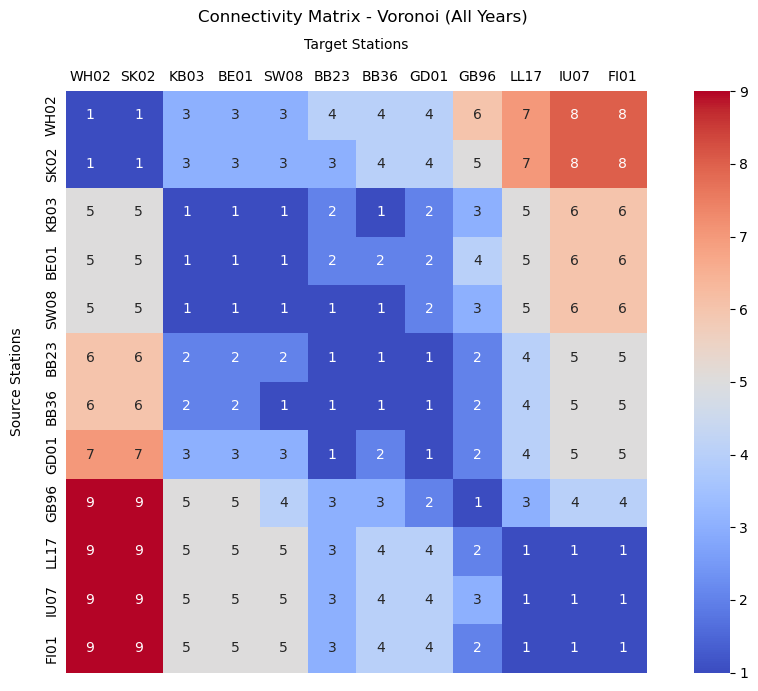

In [114]:
cmatrix = df_cmatrix_normalized_relative.copy()
generations_matrix = df_cmatrix_normalized_relative.where(cmatrix==0, 1)
for i in np.arange(2,25):
        cmatrix = df_cmatrix_normalized_relative.dot(cmatrix)
        generations_matrix = generations_matrix.where((generations_matrix[generations_matrix == 0].isnull()) | (cmatrix==0), i)
        if generations_matrix.min(axis=None) != 0:
                break
showConnectivityMatrix(generations_matrix, no_digital=True, cbtitle="", cmdiscrete=False)


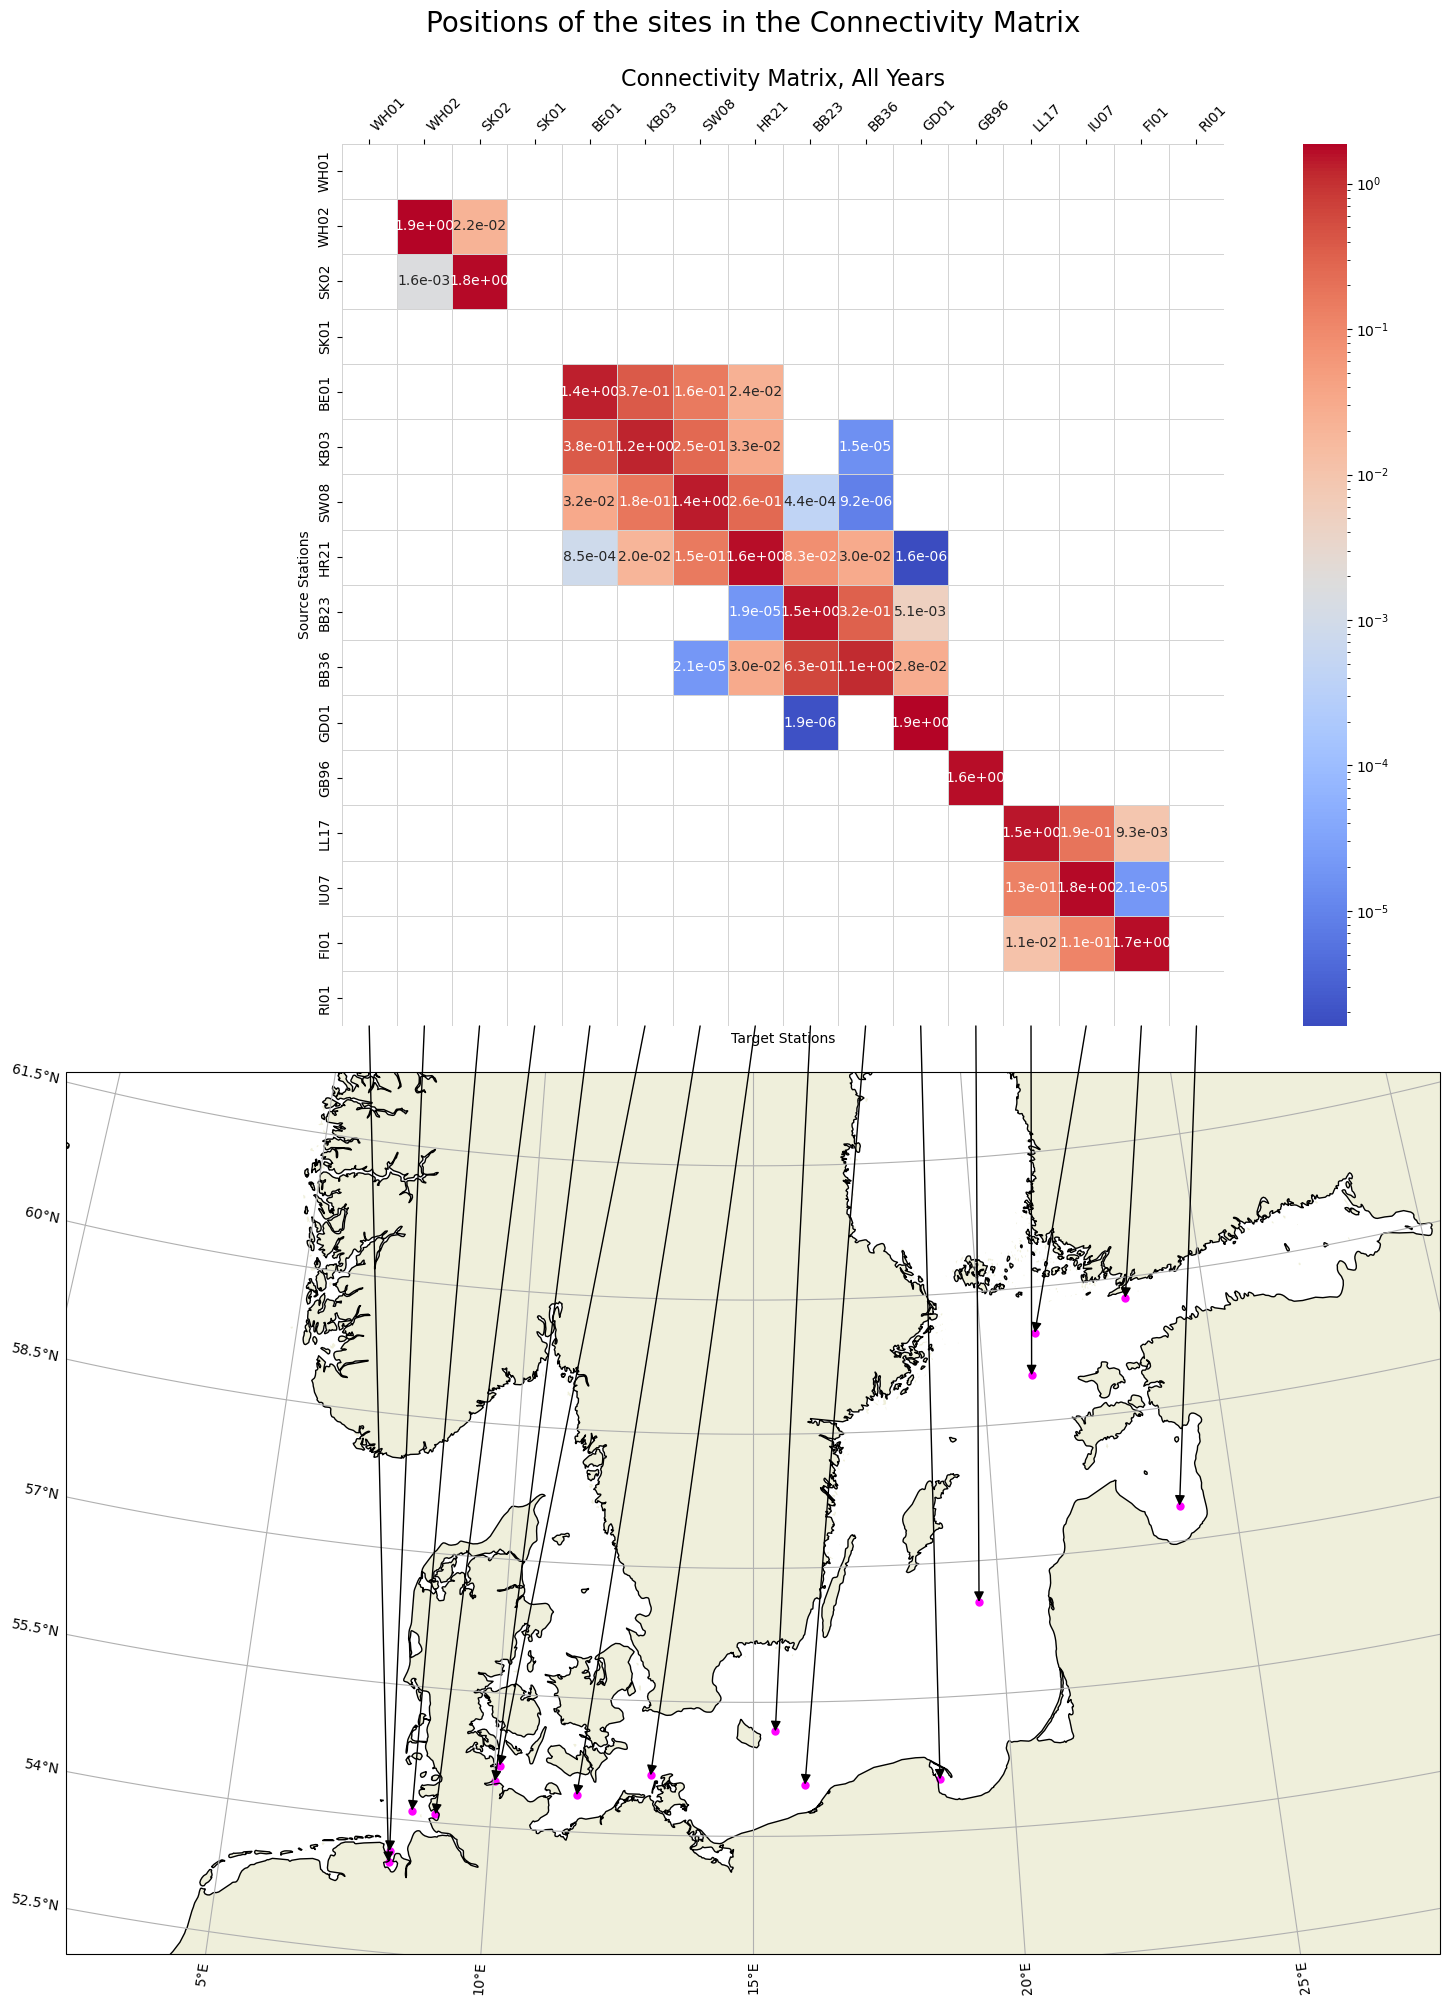

In [17]:
matrix = df_cmatrix_total_pc
mask = matrix == 0
fig = plt.figure(figsize=(16,20))
fig.suptitle(
    "Positions of the sites in the Connectivity Matrix",
    y=1, size=suptitle_size,
    )

ax_matrix = fig.add_subplot(2,1,1)
ax_matrix.set_title(
    "Connectivity Matrix, All Years",
    size=title_size
    )
sns.heatmap(
    matrix,
    annot=True, 
    fmt=".1e",
    cmap="coolwarm", 
    linecolor="lightgrey",
    cbar=True,
    mask=mask,
    linewidths=0.5,
    norm=LogNorm(),
    square=True,
    ax=ax_matrix,
)
ax_matrix.xaxis.tick_top()
ax_matrix.set_xticklabels(ax_matrix.get_xticklabels(), rotation=45, ha='left')
ax_matrix.set_xlabel("Target Stations")
ax_matrix.set_ylabel("Source Stations")

ax_map = fig.add_subplot(212, projection=map_projection,)
basemap(ax_map)
map_sites(ax_map)

# Connecting lines between Plots
for i, lon in enumerate(df_locations_sorted.lon):
    lat = df_locations_sorted.lat[i]
    pos_map = map_projection.transform_point(lon, lat, PlateCarree())
    con = ConnectionPatch(
        xyA=(i+0.5,16), coordsA=ax_matrix.transData, #Positions below Matrix
        xyB=pos_map, coordsB=ax_map.transData, #Positions on map
        zorder=90,
        color="k",
    )
    con.set_arrowstyle("-|>,head_length=0.6,head_width=0.3")
    fig.add_artist(con)

plt.tight_layout()
# plt.savefig(Path(figure_outpath,"Overview.jpg"), format="png")
plt.show()

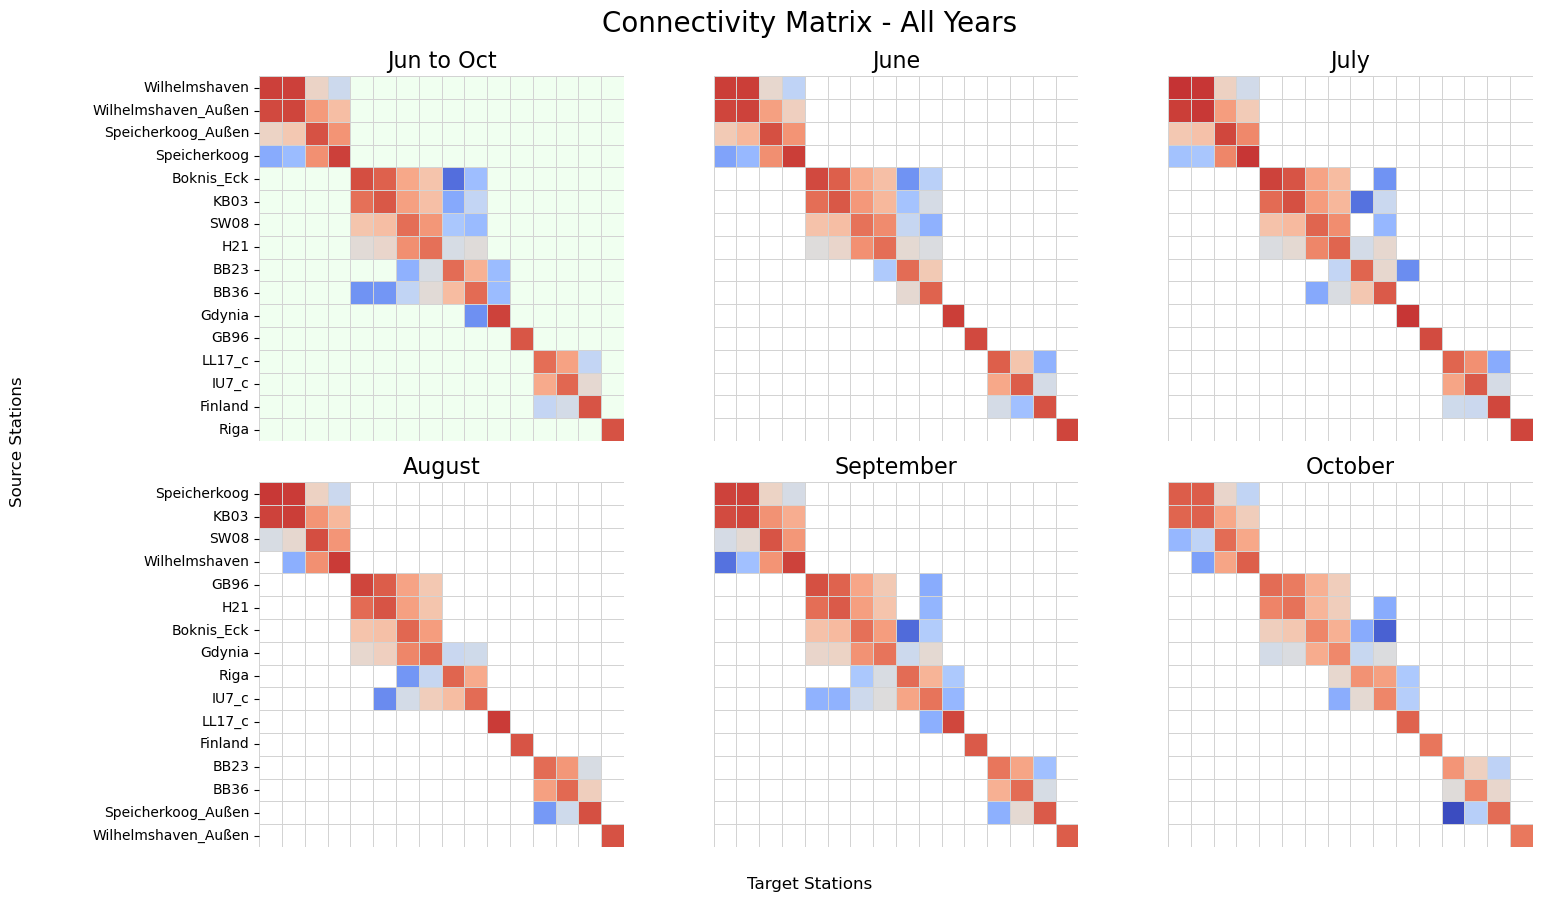

In [18]:
fig = plt.figure(figsize=(16, 9))
fig.suptitle("Connectivity Matrix - All Years", size=suptitle_size)
fig.supylabel("Source Stations", x=0)
fig.supxlabel("Target Stations", y=0)

ax = fig.add_subplot(231, fc="#f0fff0")
ax.set_title(title_months[0], size=title_size)
matrix = df_cmatrix_total_pc
mask = matrix == 0
total_cm = sns.heatmap(
    matrix,
    annot=False, 
    fmt=".1e",
    cmap="coolwarm", 
    linecolor="lightgrey",
    mask = mask,
    square=True,
    linewidths=0.5,
    norm=LogNorm(vmin=matrix_min, vmax=10,),
    xticklabels=False,
    cbar=False,
)

for month, matrix in monthly_connectivity_matrix.items():
    ax = fig.add_subplot(int(str(f"23{month-4}")))
    mask = matrix == 0
    hm = sns.heatmap(
        matrix,
        annot=False, 
        fmt=".1e",
        cmap="coolwarm", 
        linecolor="lightgrey",
        mask=mask,
        square=True,
        linewidths=0.5,
        norm=LogNorm(vmin=matrix_min, vmax=10,),
        xticklabels=False,
        cbar=False,
    )
    if month == 8:
        hm.set_yticklabels(location_names)
    else:
        plt.yticks([])
    ax.set_title(title_months[month], size=title_size)
plt.tight_layout()
plt.savefig(Path(figure_outpath,"ConnectivityMatricesMonthlyComparrison.jpg"), format="png")
plt.show()

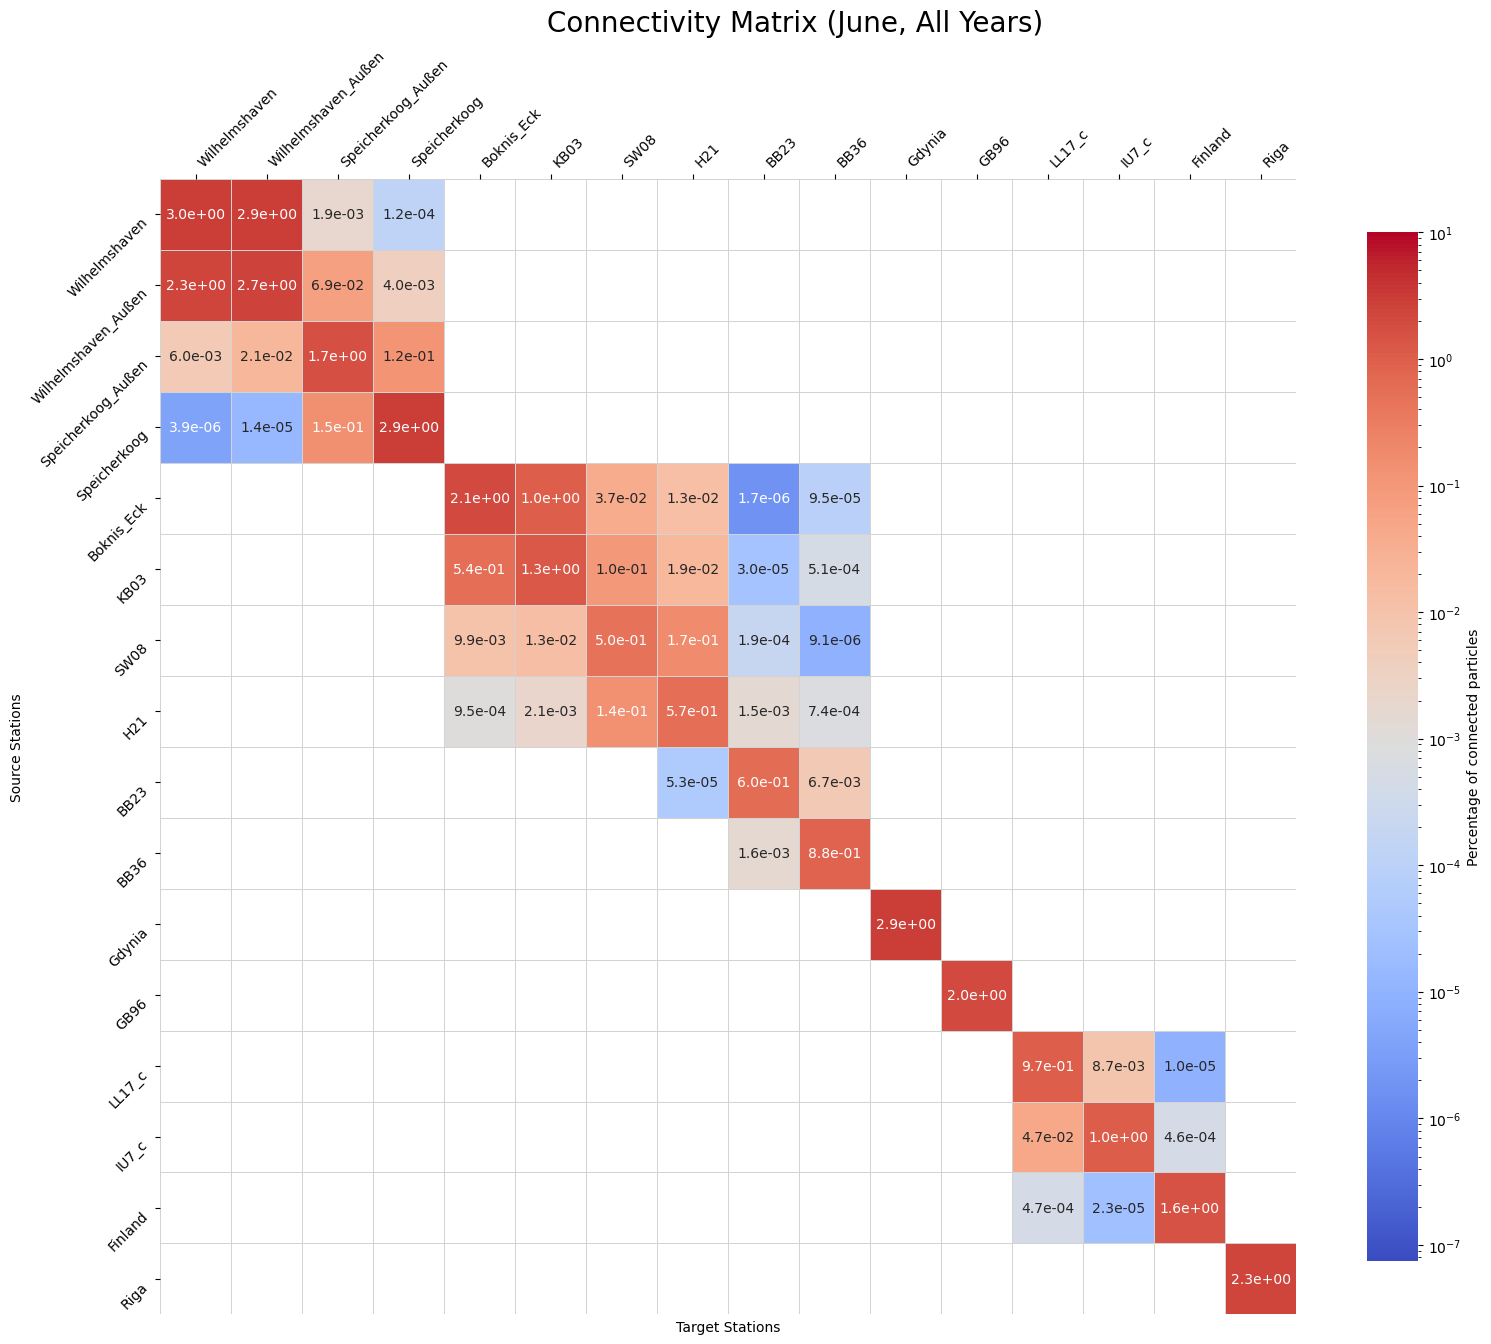

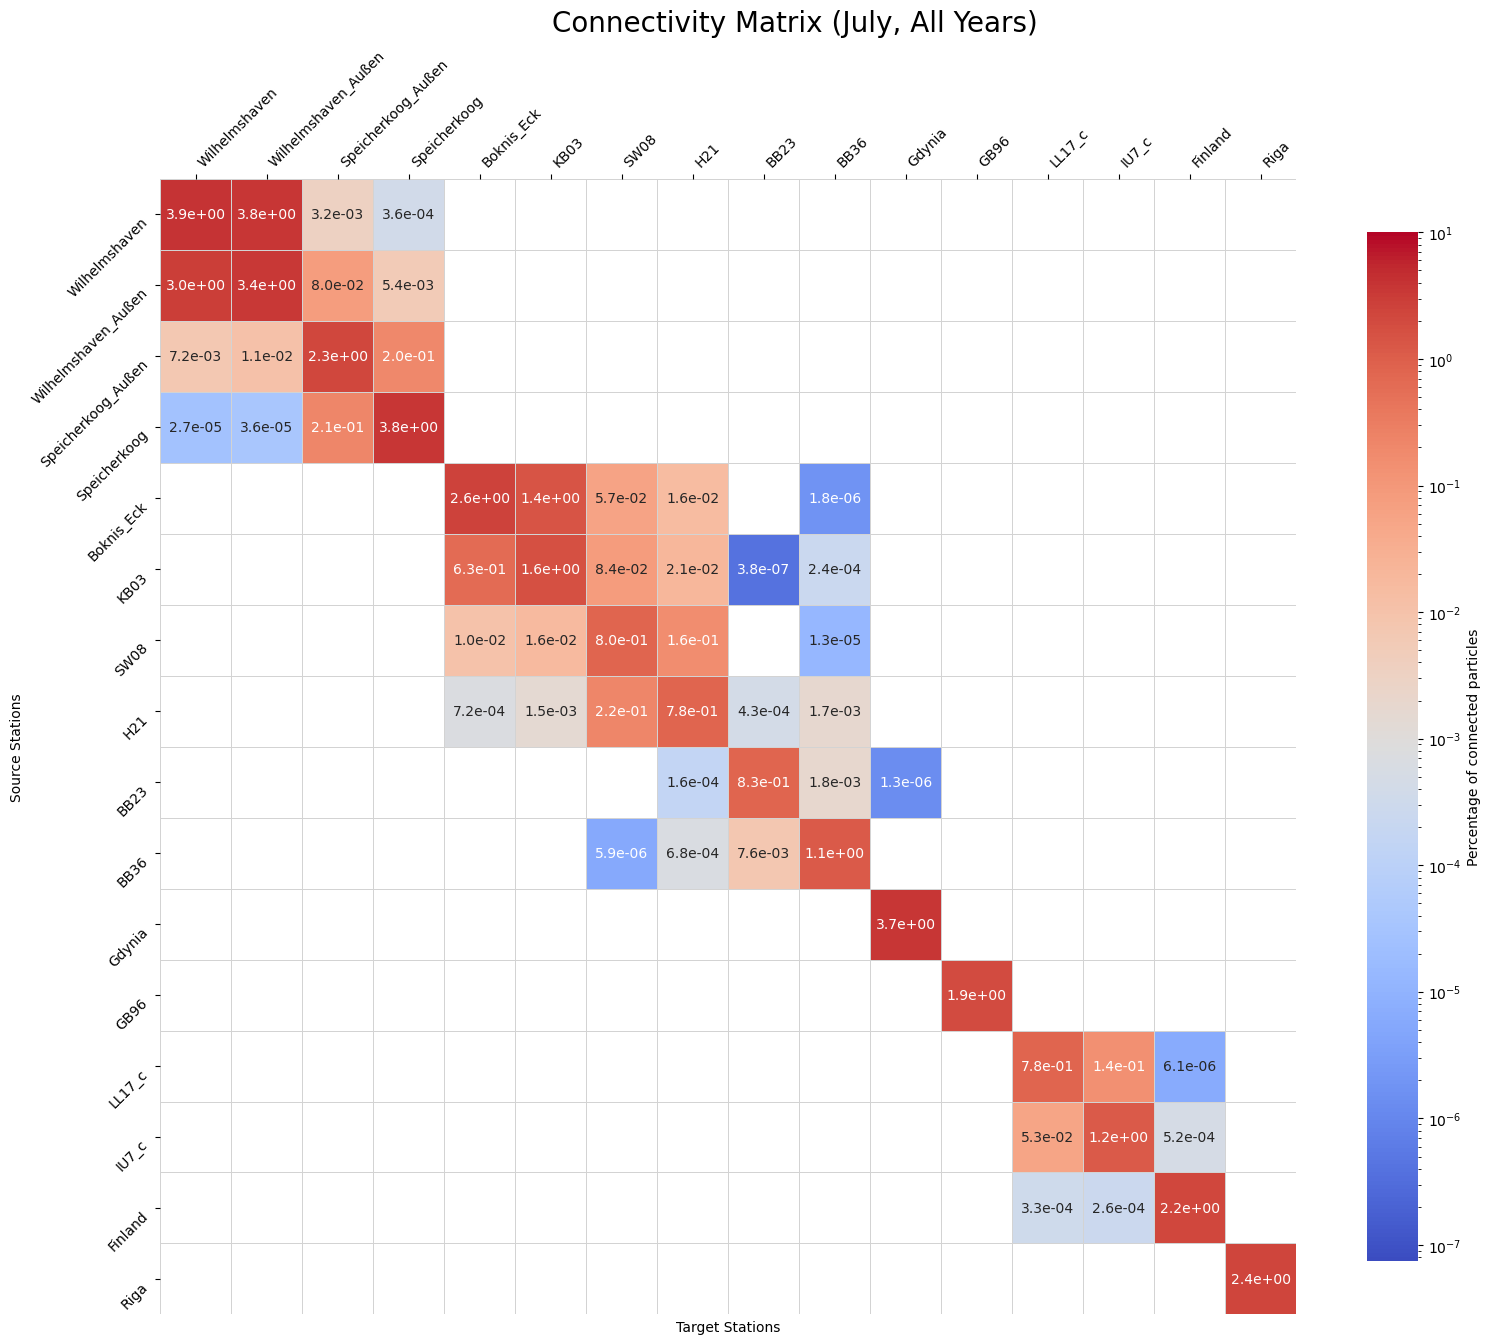

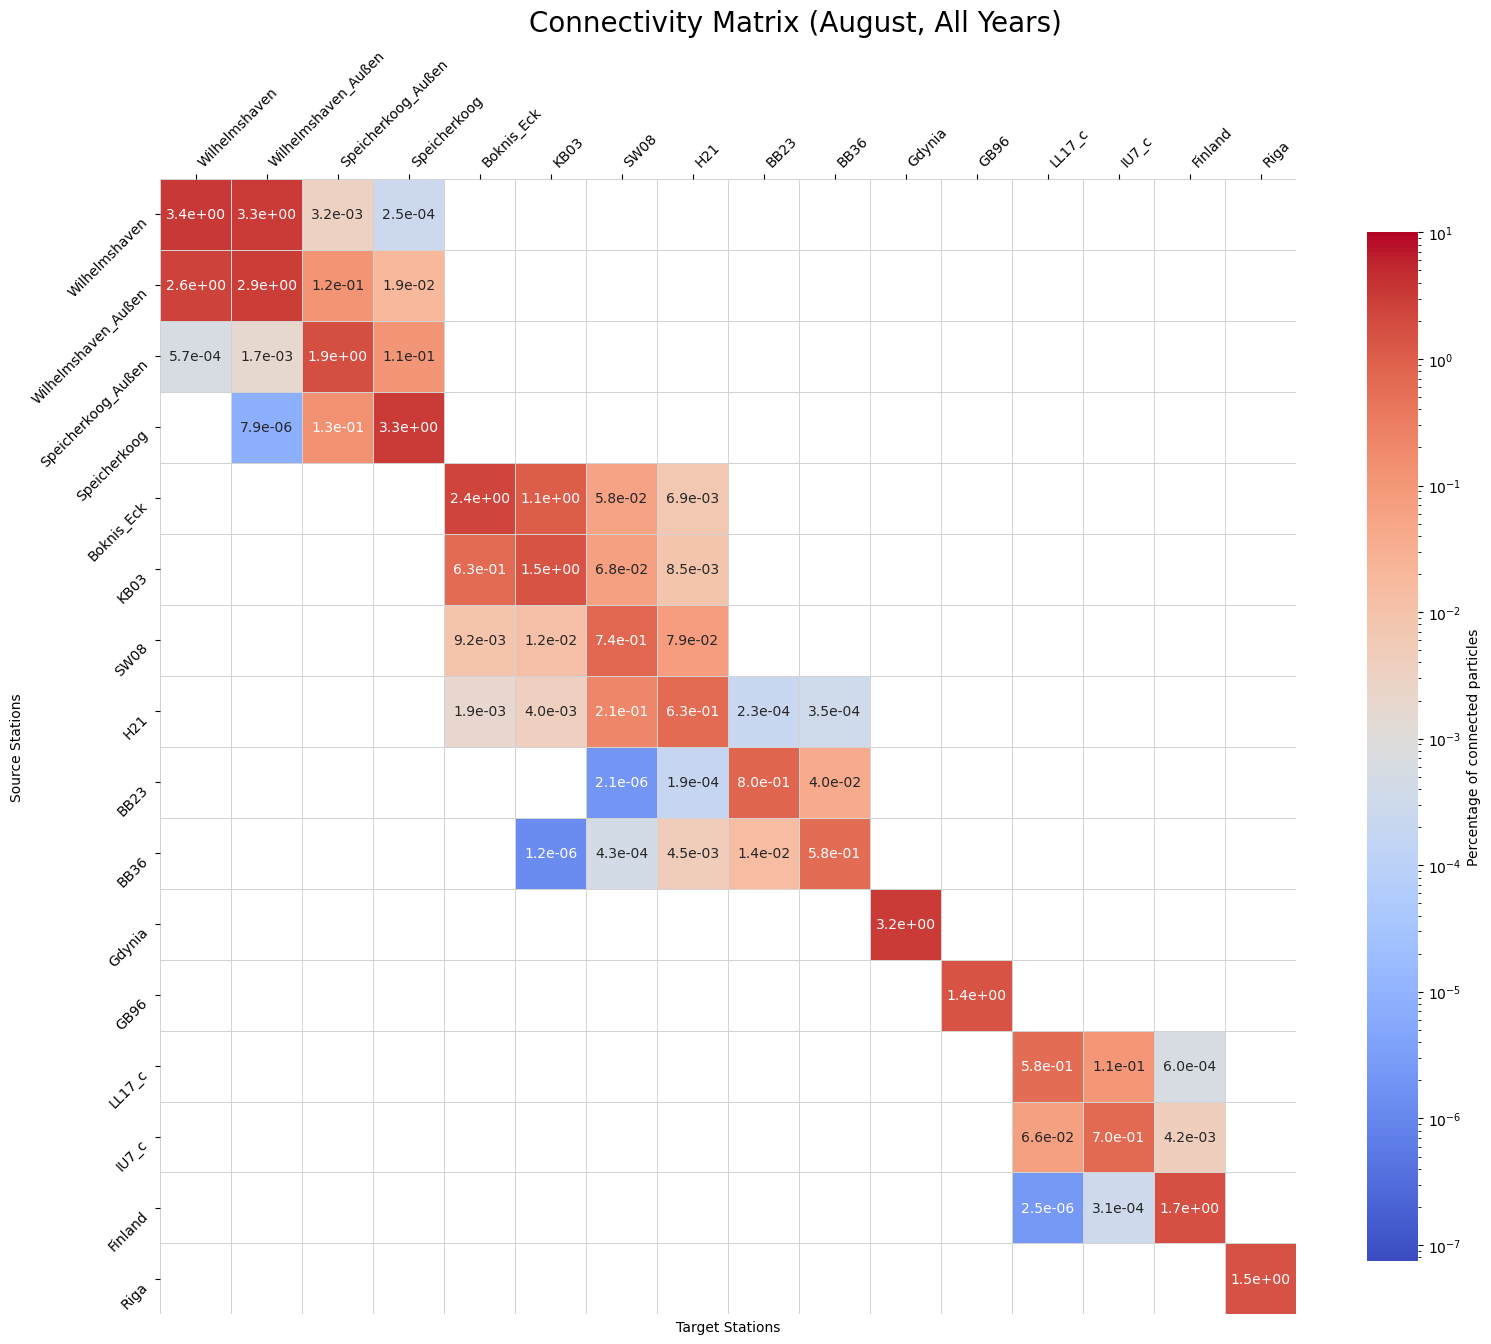

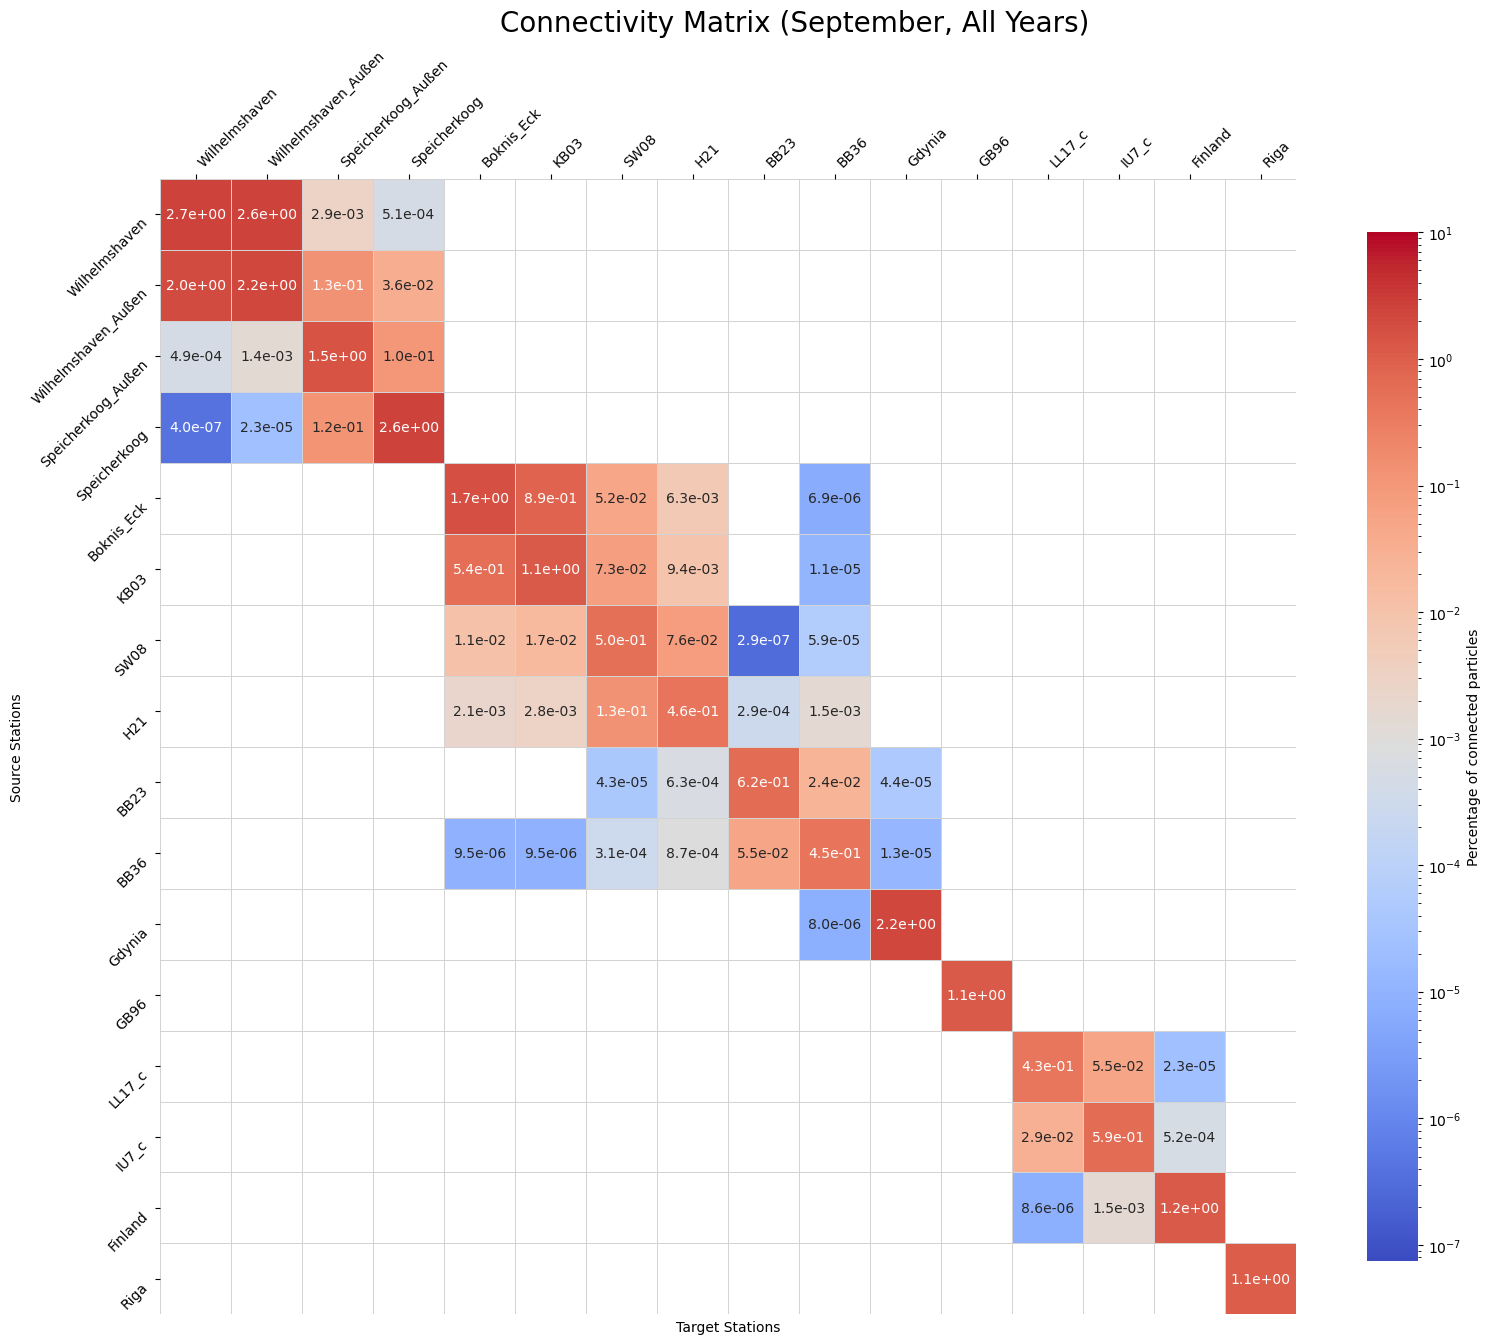

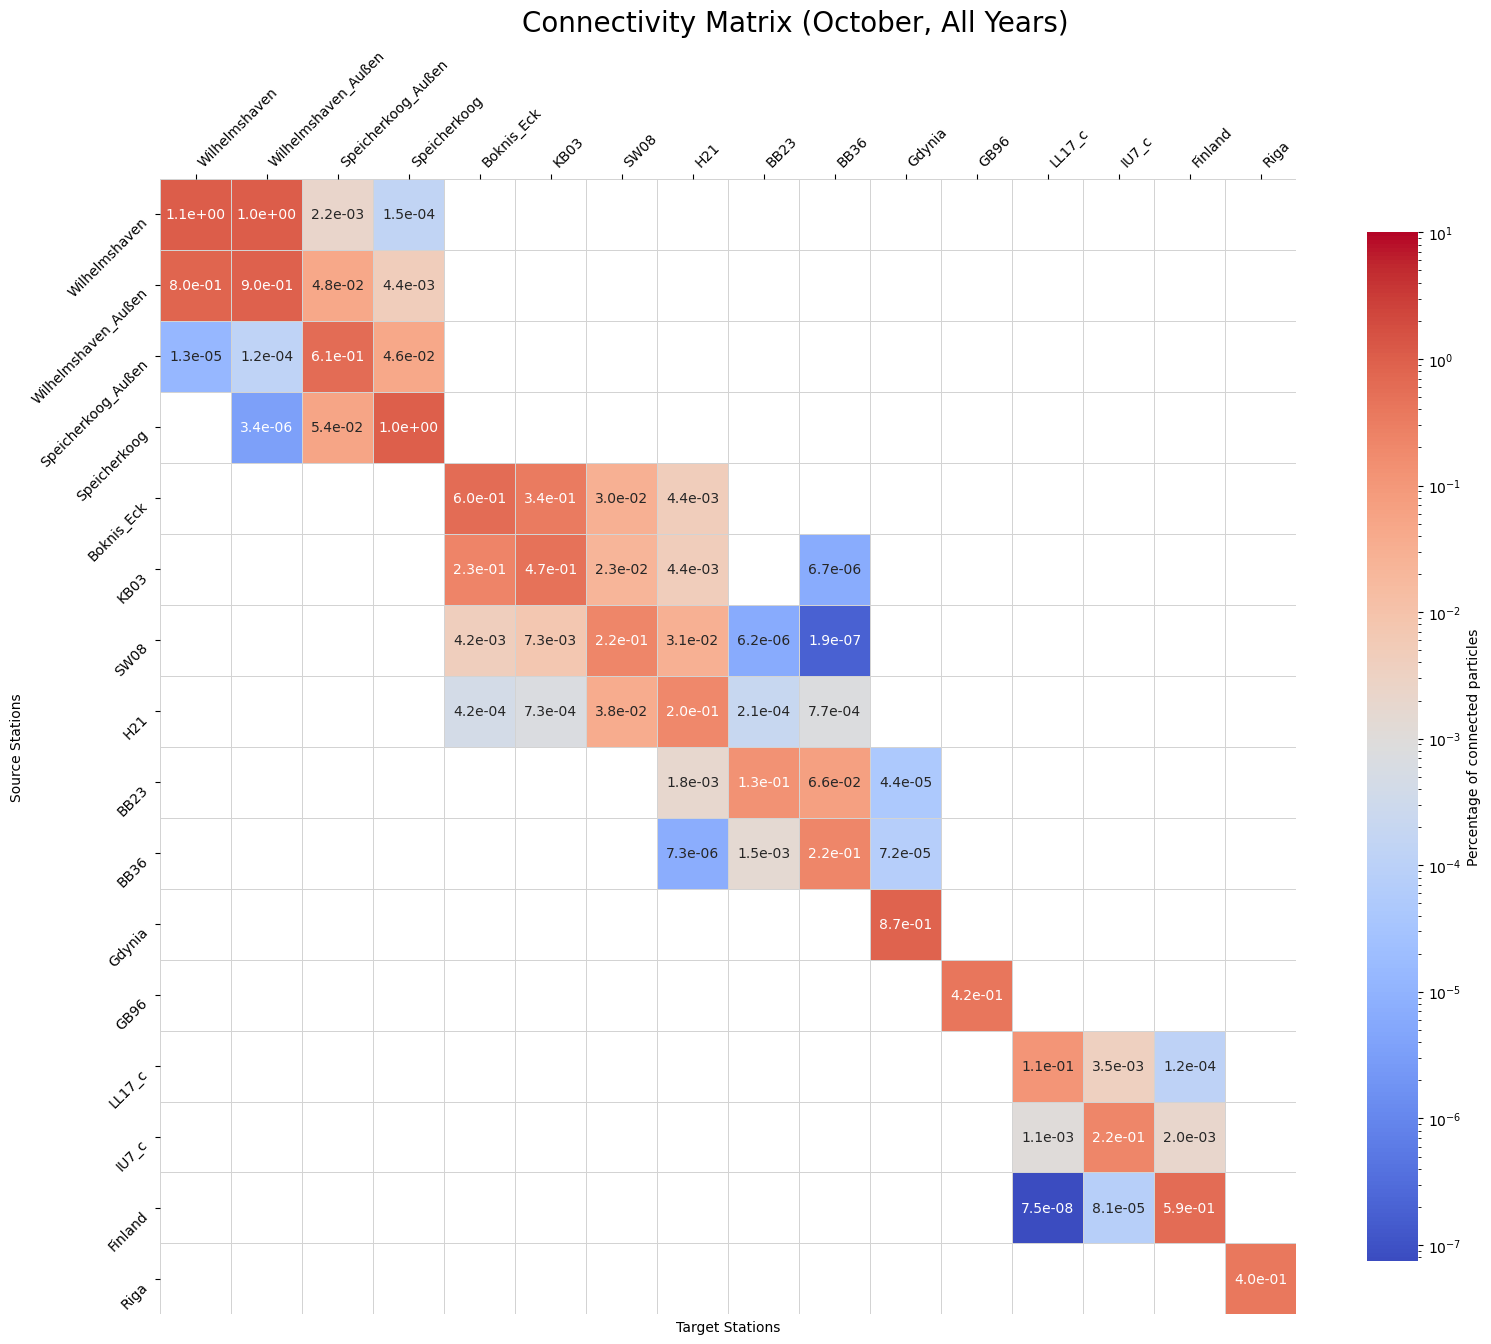

In [21]:
for m in np.arange(6,11):
    showConnectivityMatrix(monthly_connectivity_matrix, m,
    # fn=f"ConnectivityMatrix{title_months[m]}.png"
    )

# Maps

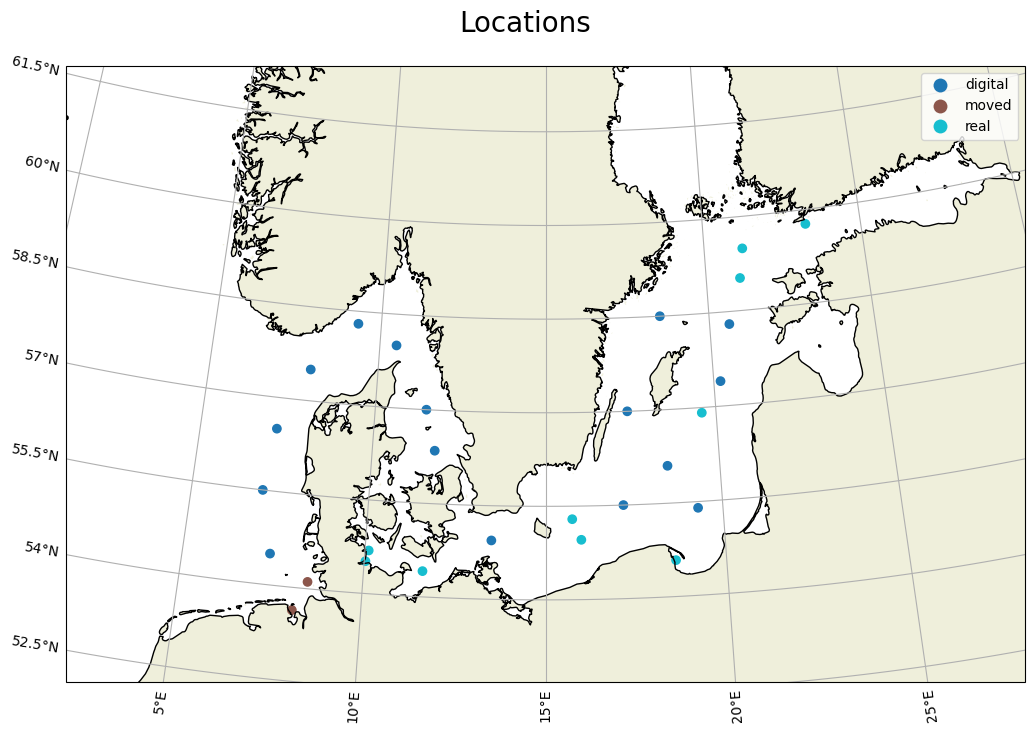

In [ ]:
fig = plt.figure(figsize=mapsize)
fig.suptitle("Locations", size=suptitle_size, y=0.95)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
# Add the red dots for the non sampled points
gdf_sample_points.to_crs(map_projection).plot(ax=ax_map,column="SampleKind", legend=True)
# plt.savefig(Path(figure_outpath, "EmptyMap.png"), format="png")
plt.show()

## Connectivity Map

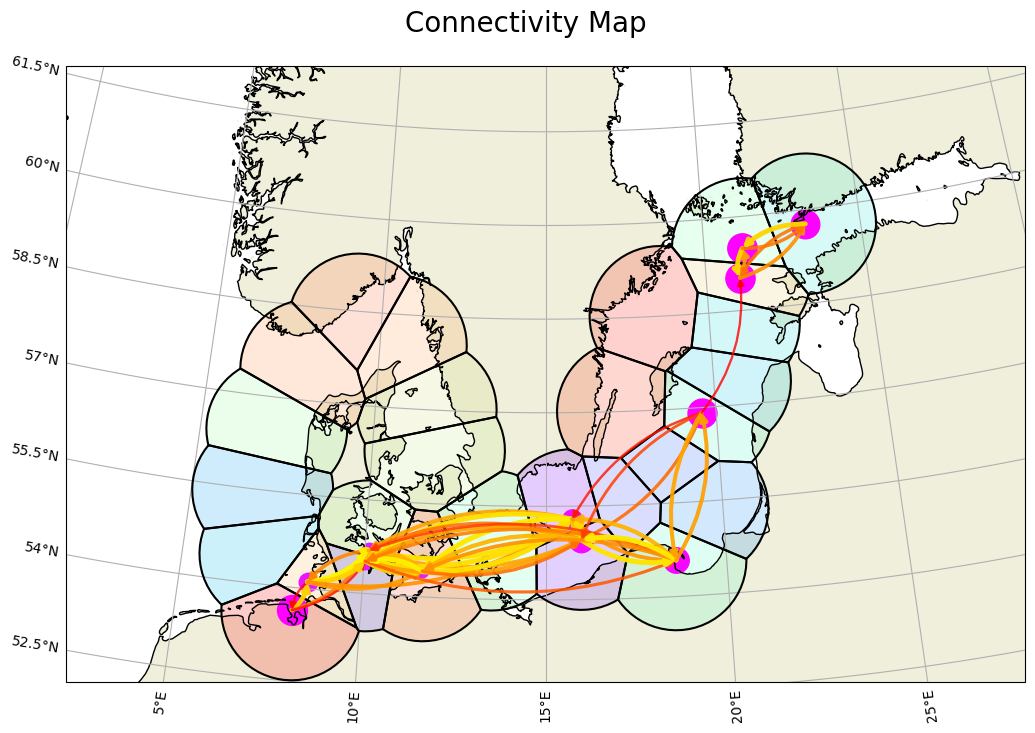

In [30]:
no_digital = True
matrix = df_cmatrix_normalized
mask = matrix == 0
sample_points = gdf_sample_points.sort_values(by="order")
if no_digital == True:
      matrix = matrix.drop(columns=nondigitalSamples.dropna().values.T[0], index=nondigitalSamples.dropna().values.T[0])
      sample_points = sample_points.get(nondigitalSamples.notnull().values)
min_connection = matrix.mask(mask).min().min()
max_connection = matrix.max().max()

fig = plt.figure(figsize=mapsize)
fig.suptitle("Connectivity Map", size=suptitle_size, y=0.95)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
cmap_arrows = mpl.colormaps.get_cmap("autumn")
cmap_self = mpl.colormaps.get_cmap("cool")
lognorm = LogNorm(vmin=min_connection, vmax=max_connection)
gdf_voronoi_polygons.to_crs(map_projection).plot(ax=ax_map, alpha=0.2, column="PolygonID", cmap="rainbow")
gdf_voronoi_polygons.boundary.to_crs(map_projection).plot(ax=ax_map, color="k", )
for i, start in enumerate(sample_points.geometry):
      for j, end in enumerate(sample_points.geometry):
            n_connections = matrix.iloc[i].iloc[j]
            if n_connections != 0:
                  con_alpha = (n_connections/max_connection)**(1/60)
                  con_lw = (n_connections/max_connection)**(1/15)
                  con_size = (n_connections/max_connection)
                  start_lon, start_lat = start.x, start.y
                  end_lon, end_lat = end.x, end.y

                  xyA = map_projection.transform_point(start_lon, start_lat, PlateCarree())
                  xyB = map_projection.transform_point(end_lon, end_lat, PlateCarree())

                  if i == j:
                        color = cmap_self(lognorm(n_connections))
                        ax_map.scatter(
                              start_lon, start_lat,
                              s=con_size*500,
                              transform=PlateCarree(),
                              c=color,
                              )
                  else:
                        color = cmap_arrows(lognorm(n_connections))
                        con = ConnectionPatch(
                              xyA=xyA, coordsA=ax_map.transData,
                              xyB=xyB, coordsB=ax_map.transData,
                              lw=con_lw*4,
                              color=color,
                              alpha=con_alpha,
                        )
                        con.set_arrowstyle("-|>,head_length=0.4,widthB=1")
                        con.set_connectionstyle("Arc3,rad=0.2")
                        fig.add_artist(con)
        
# make_cbar(fig, ax_map, hist)
# # plt.savefig(Path(figure_outpath, "ConnectivityMap.jpg"), format="png")
plt.show()

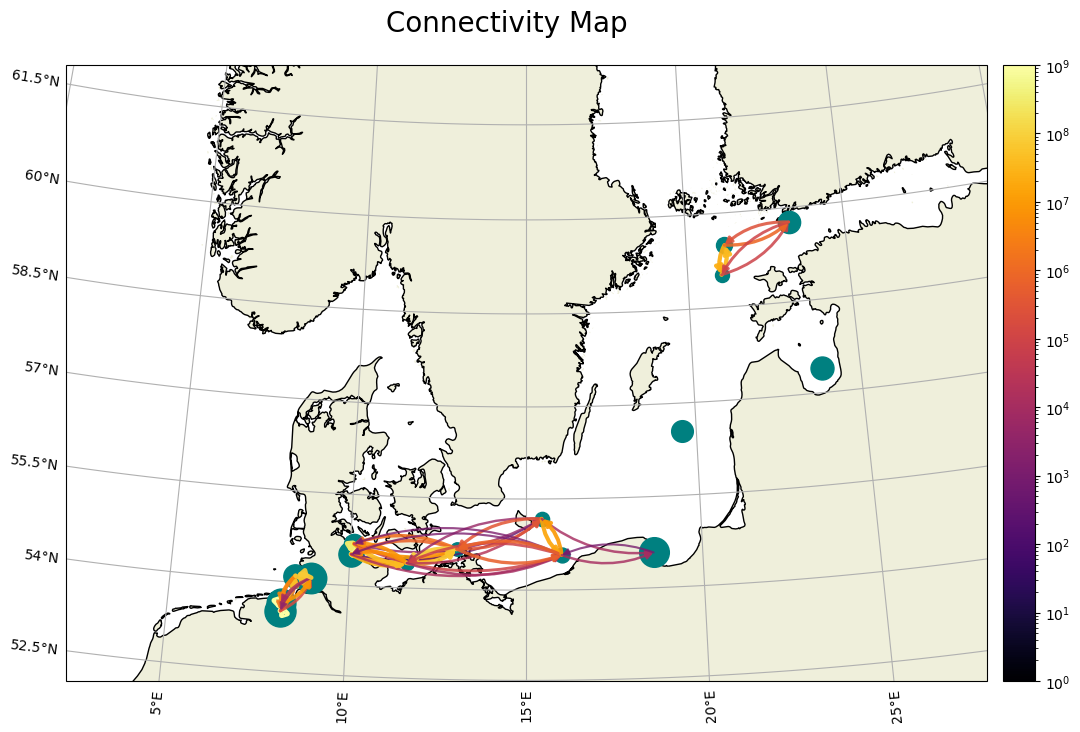

In [ ]:
max_connection = df_cmatrix_total.max().max()
fig = plt.figure(figsize=mapsize)
fig.suptitle("Connectivity Map", size=suptitle_size, y=0.95)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
cmap = mpl.colormaps.get_cmap("inferno")

hist = ax_map.pcolormesh(
   lonbinsage, latbinsage, 
   age_3d[:-1, :-1, 0], 
   norm=lognorm,
   transform=PlateCarree(),
   cmap=cmap,
   )
for i in range(len(lons)):
    for j in range(len(lons)):
        start_lon, start_lat = df_locations_sorted.lon[i], df_locations_sorted.lat[i]
        end_lon, end_lat = df_locations_sorted.lon[j], df_locations_sorted.lat[j]
        xyA = map_projection.transform_point(
            start_lon, start_lat, PlateCarree()
            )
        xyB = map_projection.transform_point(
            end_lon, end_lat, PlateCarree()
            )

        n_connections = df_cmatrix_total.iloc[i].iloc[j]
        color = cmap(lognorm(n_connections))
        if n_connections == 0:
            con_alpha = 0
        else:
            con_alpha = (n_connections/max_connection)**(1/60)
            con_lw = (n_connections/max_connection)**(1/15)
            con_size = (n_connections/max_connection)
        if i == j:
            ax_map.scatter(
                start_lon,start_lat,
                s=con_size*500, zorder=100,
                transform=PlateCarree(),
                c="teal",
                )
        else:
            con = ConnectionPatch(
                xyA=xyA, coordsA=ax_map.transData,
                xyB=xyB, coordsB=ax_map.transData,
                zorder=80,
                lw=con_lw*4,
                color=color,
                alpha=con_alpha,
            )
            con.set_arrowstyle("-|>,head_length=0.4,widthB=1")
            con.set_connectionstyle("Arc3,rad=0.2")
            fig.add_artist(con)
        
make_cbar(fig, ax_map, hist)
# plt.savefig(Path(figure_outpath, "ConnectivityMap.jpg"), format="png")
plt.show()

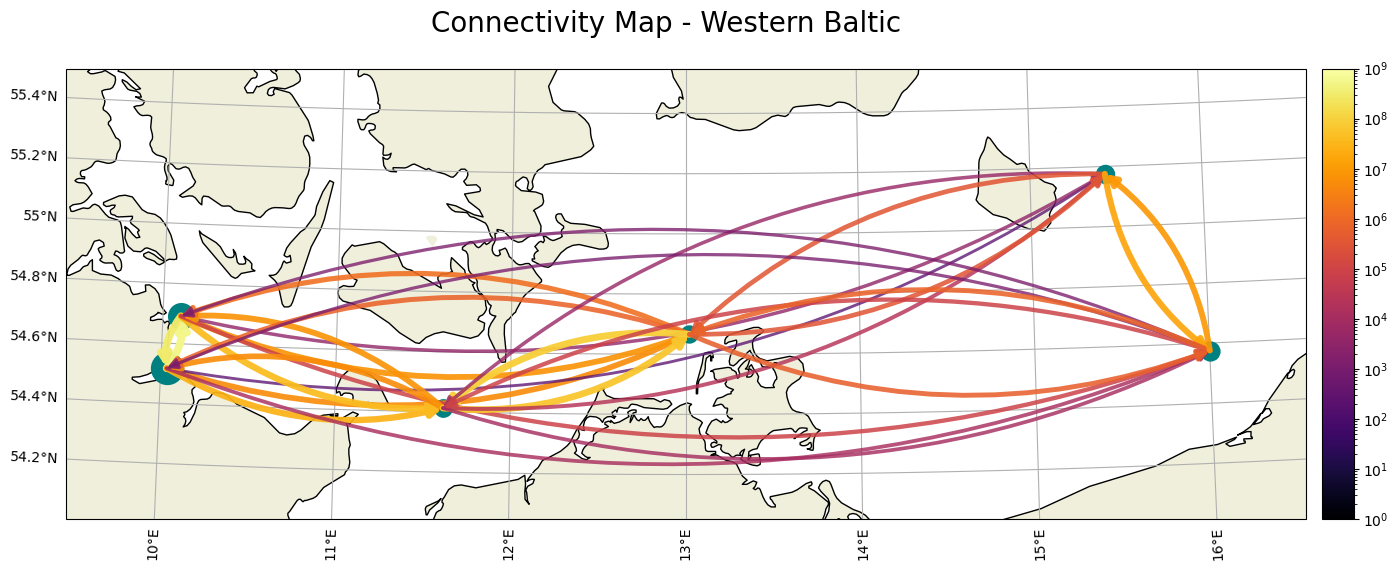

In [50]:
max_connection = df_cmatrix_total.max().max()
close_extent = (7.5,19,53,55.5)
close_extent = (9.5,16.5,54,55.5)
close_map_projection = Stereographic(
    central_longitude=np.mean(close_extent[:2]),
    central_latitude=np.mean(close_extent[2:]),
    )
fig = plt.figure(figsize=mapsize)
fig.suptitle("Connectivity Map - Western Baltic", size=suptitle_size, y=0.85)
ax_map = fig.add_subplot(
    projection=close_map_projection
)
ax_map.set_extent(close_extent, PlateCarree())
ax_map.add_feature(cartopy.feature.LAND)
ax_map.add_feature(cartopy.feature.COASTLINE)
ax_map.gridlines(draw_labels=["left", "bottom"], y_inline=False,)


cmap = mpl.colormaps.get_cmap("inferno")
hist = ax_map.pcolormesh(
   lonbinsage, latbinsage,
   age_3d[:-1, :-1, 0], 
   norm=lognorm,
   transform=PlateCarree(),
   cmap=cmap,
   )
for i in range(len(lons)):
    for j in range(len(lons)):
        start_lon = df_locations_sorted.lon[i]
        start_lat = df_locations_sorted.lat[i]
        end_lon = df_locations_sorted.lon[j]
        end_lat = df_locations_sorted.lat[j]
        if (
            (start_lon > close_extent[0]) and
            (start_lon < close_extent[1]) and
            (end_lon > close_extent[0]) and
            (end_lon < close_extent[1])
        ):
            xyA = close_map_projection.transform_point(
                start_lon, start_lat, PlateCarree()
                )
            xyB = close_map_projection.transform_point(
                end_lon, end_lat, PlateCarree()
                )

            n_connections = df_cmatrix_total.iloc[i].iloc[j]
            norm = LogNorm(vmin=1, vmax=1e9)
            color = cmap(lognorm(n_connections))
            if n_connections == 0:
                con_alpha = 0
            else:
                con_alpha = (n_connections/max_connection)**(1/60)
                con_lw = (n_connections/max_connection)**(1/15)
                con_size = (n_connections/max_connection)
            if i == j:
                ax_map.scatter(
                    start_lon,start_lat,
                    s=con_size*800, zorder=100,
                    transform=PlateCarree(),
                    c="teal",
                    )
            else:
                con = ConnectionPatch(
                    xyA=xyA, coordsA=ax_map.transData,
                    xyB=xyB, coordsB=ax_map.transData,
                    zorder=80,
                    lw=con_lw*6,
                    color=color,
                    alpha=con_alpha,
                )
                con.set_arrowstyle("-|>,head_length=0.6,head_width=0.3")
                con.set_connectionstyle("Arc3,rad=0.2")
                fig.add_artist(con)

make_cbar(fig, ax_map, hist)
plt.savefig(Path(figure_outpath, "ConnectivityMapWestBaltic.jpg"), format="png")
plt.show()

# Pelagic Heatmap

In [43]:
pelagic_hist = xr.open_dataset(Path("output/PelagicConnectivity/ds_pelagicConnectivity_2024_s02.nc"))
pelagic_hist_total = pelagic_hist["1-2-0"].sum(dim=["age", "start_day","time","site"])
